In [8]:
pip install tensorflow matplotlib seaborn scikit-learn pandas

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AveragePooling2D
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [10]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

print(x_train.shape)
print(x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1668s 10us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [11]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

/tmp/ipykernel_1511/707852606.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


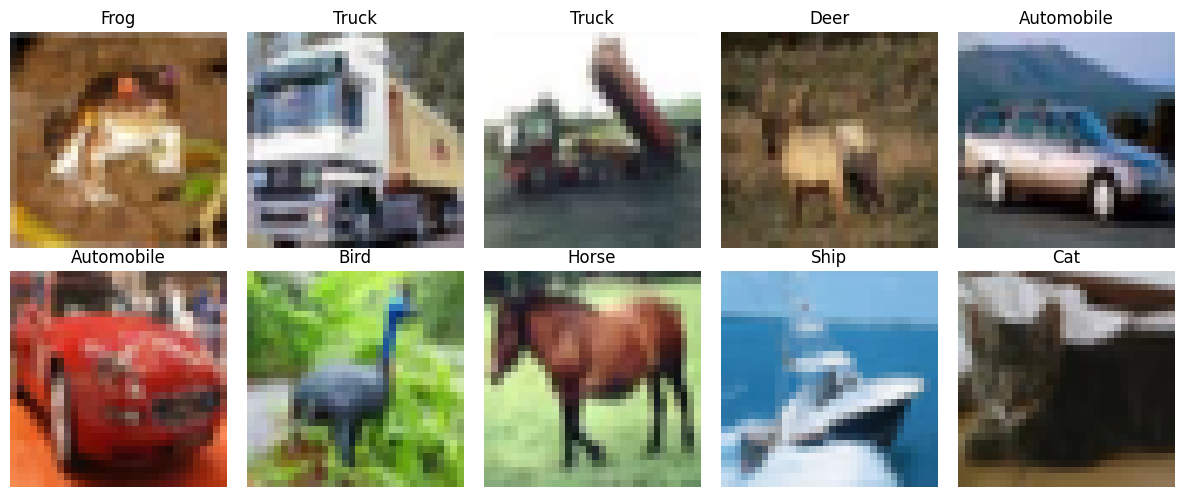

In [12]:
plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i])])
    plt.axis("off")

plt.tight_layout()
plt.savefig("SampleImages.eps", format="eps")
plt.show()

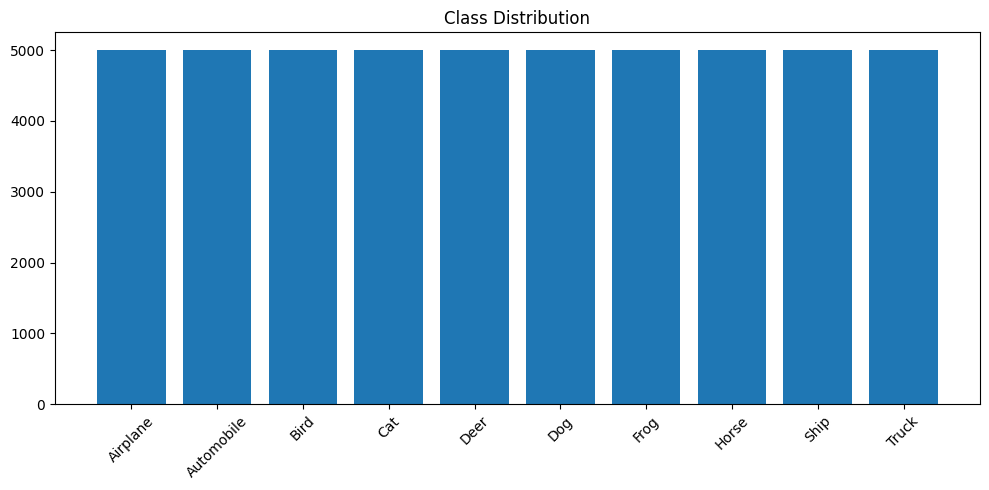

In [13]:
counts = np.bincount(y_train.flatten())

plt.figure(figsize=(10,5))
plt.bar(class_names, counts)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.tight_layout()

plt.savefig("ClassDistribution.eps", format="eps")
plt.show()

In [14]:
model = Sequential()

model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    padding='same',
    input_shape=(32,32,3)
))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
))

model.add(MaxPooling2D((2,2)))

model.add(Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
))

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10,activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
history = model.fit(
    x_train,
    y_train_cat,
    epochs=15,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 102ms/step - accuracy: 0.3997 - loss: 1.6289 - val_accuracy: 0.5288 - val_loss: 1.3179
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 100ms/step - accuracy: 0.5615 - loss: 1.2303 - val_accuracy: 0.6384 - val_loss: 1.0337
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 99ms/step - accuracy: 0.6370 - loss: 1.0304 - val_accuracy: 0.6703 - val_loss: 0.9461
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 101ms/step - accuracy: 0.6839 - loss: 0.9044 - val_accuracy: 0.6969 - val_loss: 0.8513
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 64s 103ms/step - accuracy: 0.7181 - loss: 0.8108 - val_accuracy: 0.7220 - val_loss: 0.7911
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 105ms/step - accuracy: 0.7427 - loss: 0.7412 - val_accuracy: 0.7232 - val_loss: 0.7885
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 102ms/step - accuracy: 0.7679 - loss: 0.6669 - val_accuracy: 0.7407 - val_loss: 0.7499
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 101ms/step - accuracy: 0.7857 - loss: 0.

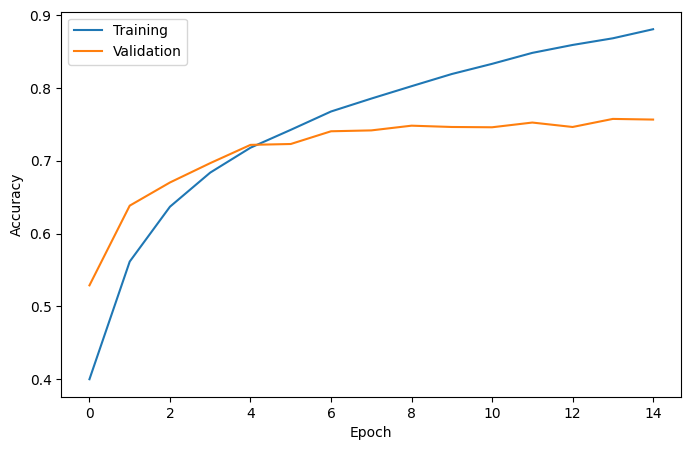

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label="Training")
plt.plot(history.history['val_accuracy'],label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("Accuracy.eps", format="eps")
plt.show()

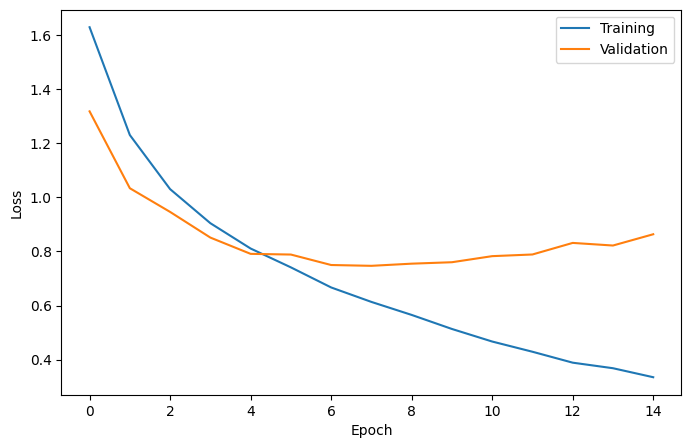

In [18]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],label="Training")
plt.plot(history.history['val_loss'],label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig("Loss.eps", format="eps")
plt.show()

In [19]:
loss, accuracy = model.evaluate(x_test,y_test_cat)

print("Accuracy =",accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7503 - loss: 0.9044
Accuracy = 0.7502999901771545


In [20]:
pred = model.predict(x_test)

pred_classes = np.argmax(pred,axis=1)

true_classes = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step


In [21]:
precision = precision_score(
    true_classes,
    pred_classes,
    average='weighted'
)

recall = recall_score(
    true_classes,
    pred_classes,
    average='weighted'
)

f1 = f1_score(
    true_classes,
    pred_classes,
    average='weighted'
)

print("Precision =",precision)
print("Recall =",recall)
print("F1 Score =",f1)

Precision = 0.75095340711454
Recall = 0.7503
F1 Score = 0.7489630467709599


In [22]:
print(classification_report(
    true_classes,
    pred_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

    Airplane       0.81      0.79      0.80      1000
  Automobile       0.87      0.88      0.87      1000
        Bird       0.70      0.58      0.63      1000
         Cat       0.55      0.56      0.56      1000
        Deer       0.71      0.71      0.71      1000
         Dog       0.68      0.63      0.65      1000
        Frog       0.71      0.88      0.79      1000
       Horse       0.78      0.79      0.79      1000
        Ship       0.90      0.84      0.86      1000
       Truck       0.80      0.84      0.82      1000

    accuracy                           0.75     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.75      0.75      0.75     10000



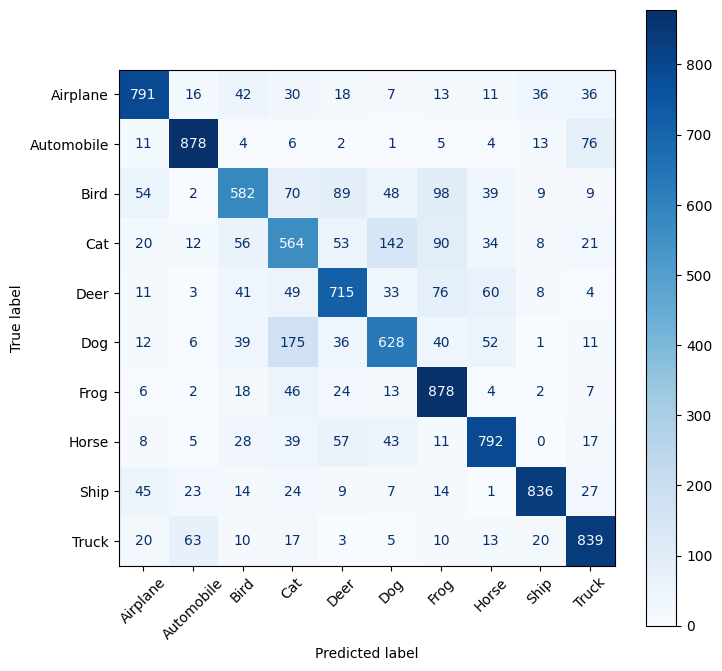

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    true_classes,
    pred_classes
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8,8))

disp.plot(ax=ax,cmap="Blues")
plt.xticks(rotation=45)

plt.savefig("ConfusionMatrix.eps", format="eps")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


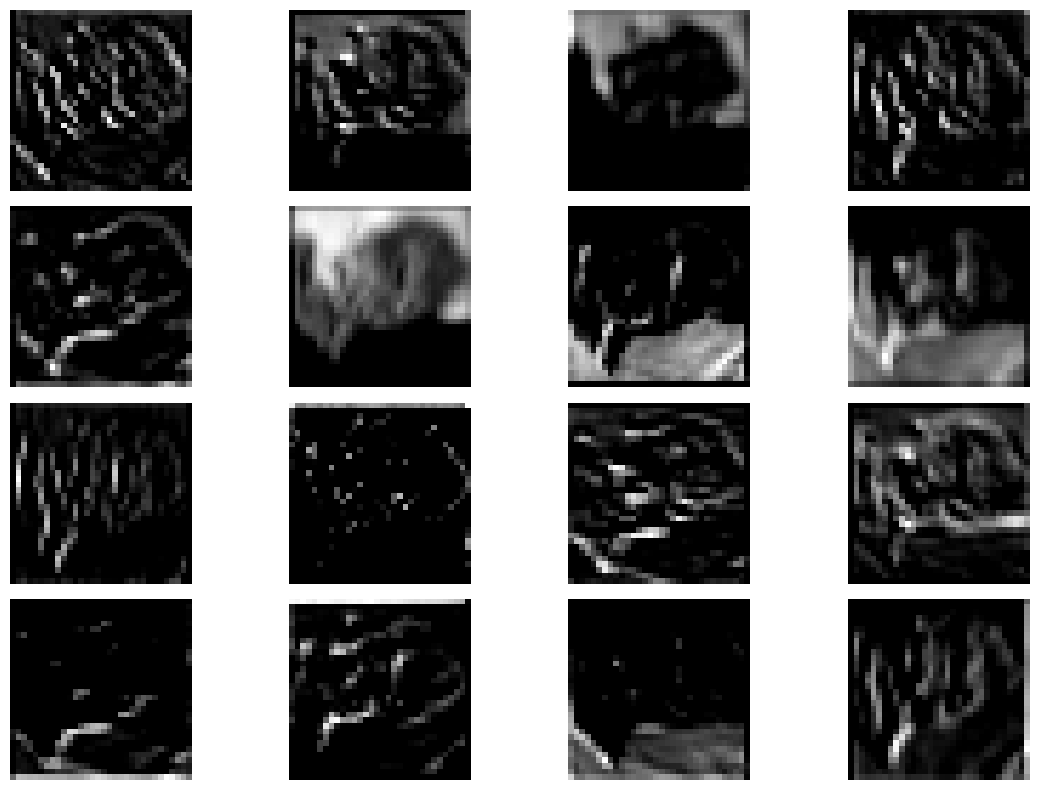

In [24]:
feature_model = Model(
    inputs=model.inputs,
    outputs=model.layers[0].output
)

feature_maps = feature_model.predict(
    x_test[0].reshape(1,32,32,3)
)

plt.figure(figsize=(12,8))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(feature_maps[0,:,:,i],cmap="gray")
    plt.axis("off")

plt.tight_layout()

plt.savefig("FeatureMaps.eps", format="eps")
plt.show()

In [25]:
for layer in model.layers:
    print(layer.name)

    print("Trainable Parameters =",
          layer.count_params())

conv2d
Trainable Parameters = 896
max_pooling2d
Trainable Parameters = 0
conv2d_1
Trainable Parameters = 18496
max_pooling2d_1
Trainable Parameters = 0
conv2d_2
Trainable Parameters = 73856
max_pooling2d_2
Trainable Parameters = 0
flatten
Trainable Parameters = 0
dense
Trainable Parameters = 524544
dropout
Trainable Parameters = 0
dense_1
Trainable Parameters = 2570


In [26]:
max_model = Sequential([
    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(32,32,3)
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(10,activation='softmax')
])

avg_model = Sequential([
    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(32,32,3)
    ),

    AveragePooling2D((2,2)),

    Flatten(),

    Dense(10,activation='softmax')
])

print("Max Pooling Model")
max_model.summary()

print()

print("Average Pooling Model")
avg_model.summary()

Max Pooling Model


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        81,930 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,826 (323.54 KB)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 16, 16, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        81,930 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,826 (323.54 KB)

 Trainable params: 82,826 (323.54 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
print("Kernel Size :", (3,3))
print("Stride :", 1)
print("Padding : same")
print("Filters :", [32,64,128])
print("Optimizer : Adam")
print("Batch Size :",64)
print("Epochs :",15)

Kernel Size : (3, 3)
Stride : 1
Padding : same
Filters : [32, 64, 128]
Optimizer : Adam
Batch Size : 64
Epochs : 15
